In [6]:
import torch

print(torch.backends.mps.is_available())

True


In [7]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

In [8]:
import pandas as pd
import re
import nltk
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords, wordnet
from nltk import pos_tag
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import (Input, Embedding, Conv1D, GlobalMaxPooling1D,
                                     Dense, Dropout, Concatenate)
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/charlotecalosor/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/charlotecalosor/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/charlotecalosor/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/charlotecalosor/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [9]:
df = pd.read_csv('/Users/charlotecalosor/Downloads/SEMI-CLEANED(with Rating)_dataset.csv')
df.head()

,Category,Rating,Label,Review
0,Home_and_Kitchen_5,5.0,1,"Love this! Well made, sturdy, and very comfort..."
1,Home_and_Kitchen_5,5.0,1,"love it, a great upgrade from the original. I'..."
2,Home_and_Kitchen_5,5.0,1,This pillow saved my back. I love the look and...
3,Home_and_Kitchen_5,1.0,1,"Missing information on how to use it, but it i..."
4,Home_and_Kitchen_5,5.0,1,Very nice set. Good quality. We have had the s...


In [10]:
df.columns

Index(['Category', 'Rating', 'Label', 'Review'], dtype='object')

In [11]:
df

,Category,Rating,Label,Review
0,Home_and_Kitchen_5,5.0,1,"Love this! Well made, sturdy, and very comfort..."
1,Home_and_Kitchen_5,5.0,1,"love it, a great upgrade from the original. I'..."
2,Home_and_Kitchen_5,5.0,1,This pillow saved my back. I love the look and...
3,Home_and_Kitchen_5,1.0,1,"Missing information on how to use it, but it i..."
4,Home_and_Kitchen_5,5.0,1,Very nice set. Good quality. We have had the s...
...,...,...,...,...
40400,Clothing_Shoes_and_Jewelry_5,4.0,0,I had read some reviews saying that this bra r...
40401,Clothing_Shoes_and_Jewelry_5,5.0,1,I wasn't sure exactly what it would be. It is ...
40402,Clothing_Shoes_and_Jewelry_5,2.0,0,"You can wear the hood by itself, wear it with ..."
40403,Clothing_Shoes_and_Jewelry_5,1.0,1,I liked nothing about this dress. The only rea...


In [12]:
le = LabelEncoder()
y = le.fit_transform(df['Label'])
print("Classes:", le.classes_)

Classes: [0 1]


In [13]:
NUM_WORDS = 10000
MAX_LEN   = 100

tokenizer = Tokenizer(num_words=NUM_WORDS)
tokenizer.fit_on_texts(df['Review'])

X_text = tokenizer.texts_to_sequences(df['Review'])
X_text = pad_sequences(X_text, maxlen=MAX_LEN)
print("Text shape:", X_text.shape)


Text shape: (40405, 100)


In [14]:
scaler = MinMaxScaler()
X_rating = scaler.fit_transform(df[['Rating']])
print("Rating shape:", X_rating.shape)

Rating shape: (40405, 1)


In [15]:
X_text_temp, X_text_test, X_rating_temp, X_rating_test, y_temp, y_test = train_test_split(
    X_text, X_rating, y, test_size=0.10, random_state=42, stratify=y
)

X_text_train, X_text_val, X_rating_train, X_rating_val, y_train, y_val = train_test_split(
    X_text_temp, X_rating_temp, y_temp, test_size=0.111, random_state=42, stratify=y_temp
)

print(f"Train: {len(y_train)} | Val: {len(y_val)} | Test: {len(y_test)}")

Train: 32327 | Val: 4037 | Test: 4041


In [16]:
text_input = Input(shape=(MAX_LEN,), name='text_input')
x = Embedding(input_dim=NUM_WORDS + 1, output_dim=64)(text_input)
x = Conv1D(32, 5, activation='relu', kernel_regularizer=l2(0.01))(x)
x = GlobalMaxPooling1D()(x)
x = Dropout(0.6)(x)

# --- Rating branch ---
rating_input = Input(shape=(1,), name='rating_input')

# --- Combine both ---
combined = Concatenate()([x, rating_input])
combined = Dense(16, activation='relu', kernel_regularizer=l2(0.02))(combined)
combined = Dropout(0.6)(combined)
output = Dense(1, activation='sigmoid')(combined)

model = Model(inputs=[text_input, rating_input], outputs=output)

In [17]:
y = df['Label'].values   # CHANGE this to your actual column name

In [18]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)

model.compile(
    loss='binary_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

In [19]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    [X_text_train, X_rating_train],
    y_train,
    validation_data=([X_text_val, X_rating_val], y_val),
    epochs=20,
    batch_size=64,
    callbacks=[early_stop]
)


Epoch 1/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5144 - loss: 0.9316 - val_accuracy: 0.5028 - val_loss: 0.7342
Epoch 2/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5306 - loss: 0.7070 - val_accuracy: 0.6502 - val_loss: 0.6899
Epoch 3/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6666 - loss: 0.6517 - val_accuracy: 0.8155 - val_loss: 0.5430
Epoch 4/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7987 - loss: 0.5442 - val_accuracy: 0.8702 - val_loss: 0.4493
Epoch 5/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8400 - loss: 0.4780 - val_accuracy: 0.8786 - val_loss: 0.4048
Epoch 6/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8597 - loss: 0.4373 - val_accuracy: 0.8851 - val_loss: 0.3791
Epoch 7/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8741 - loss: 0.4072 - val_accuracy: 0.8878 - val_loss: 0.3667
Epoch 8/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8828 - loss: 0.3851 - val_accuracy: 0.

In [21]:
y_pred_prob = model.predict([X_text_test, X_rating_test])
y_pred = (y_pred_prob > 0.5).astype(int)

print(classification_report(y_test, y_pred, target_names=['CG', 'OR']))

127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 785us/step
              precision    recall  f1-score   support

          CG       0.91      0.90      0.91      2022
          OR       0.90      0.92      0.91      2019

    accuracy                           0.91      4041
   macro avg       0.91      0.91      0.91      4041
weighted avg       0.91      0.91      0.91      4041



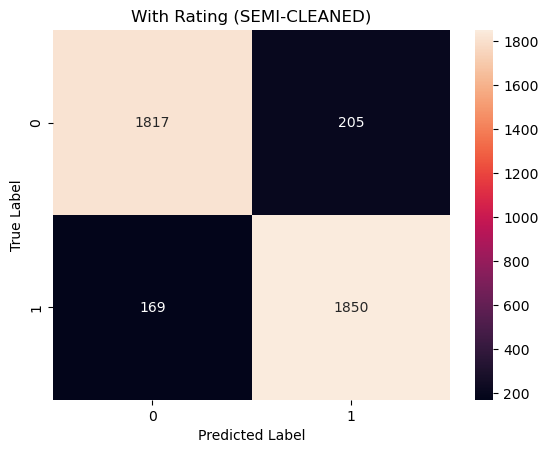

In [24]:
labels = list(le.classes_)

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels)
plt.title("With Rating (SEMI-CLEANED)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

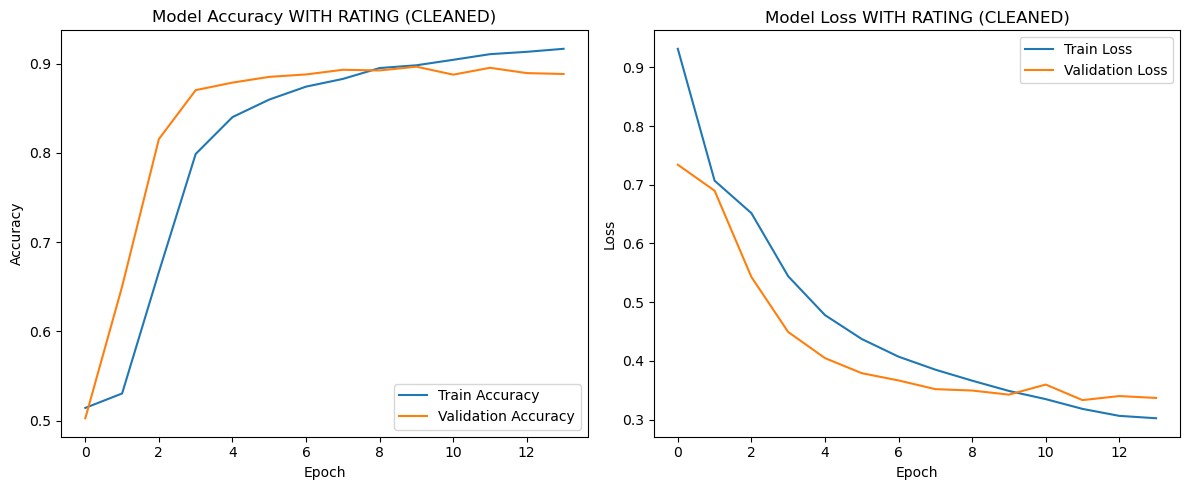

In [25]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy WITH RATING (SEMI-CLEANED)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss WITH RATING (SEMI-CLEANED)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [26]:
while True:
    new_text = input("\nEnter a review: ")
    
    if new_text.lower() == 'exit':
        print("Exiting prediction.")
        break

    new_seq = tokenizer.texts_to_sequences([new_text])
    new_padded = pad_sequences(new_seq, maxlen=MAX_LEN)
    default_rating = np.array([[0.5]])  # neutral, no scaler needed

    prediction = model.predict([new_padded, default_rating], verbose=0)

    if prediction[0][0] > 0.5:
        print(f"Prediction: OR (Original Review) — confidence: {prediction[0][0]:.2%}")
    else:
        print(f"Prediction: CG (Computer Generated) — confidence: {1 - prediction[0][0]:.2%}")


Enter a review:  The functionality is great aligned with manufacturer specifications.


Prediction: OR (Original Review) — confidence: 50.49%



Enter a review:  The build quality is exceptional and the materials used feel very durable. It is a reliable choice for long-term use.


Prediction: OR (Original Review) — confidence: 74.60%



Enter a review:  This device is easy to operate it meets the specifications in the product description.


...

Prediction: CG (Computer Generated) — confidence: 84.49%



Enter a review:  This is my purchase of the month. Thanks seller


Prediction: CG (Computer Generated) — confidence: 87.77%



Enter a review:  exit


Exiting prediction.
